# Práctica 1 - Aprendizaje Automático

## Predicción de suscripción a depósito bancario

- Miembro 1: Jorge López ALonso + 100495876
- Miembro 2: Álvaro Carrasco Fuentes + 100495918
- Semilla usada: 13

En esta versión se documenta el flujo completo de modelado:
- EDA y comprobaciones básicas de calidad de datos.
- Estrategia de evaluación (outer holdout + inner CV).
- Comparativa de modelos base y modelos adicionales.
- Búsqueda de hiperparámetros (árbol y KNN).
- Selección final, evaluación en test y generación de artefactos (`modelo_final.joblib` y `predicciones.csv`).

In [1]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

SEED = 13
MAIN_METRIC = make_scorer(f1_score, pos_label='yes')

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

### Bloque 1 - Configuración e imports

**Qué hace este bloque**
- Importa librerías de análisis, visualización y modelado.
- Define semilla (`SEED=13`) y métrica principal (F1 para clase positiva `yes`).

**Reflexión**
- Dejar fija la semilla mejora la reproducibilidad.
- Elegir F1 para la clase positiva es adecuado porque prioriza el equilibrio entre precisión y recall en la clase objetivo.

In [2]:
df = pd.read_pickle('bank_13.pkl')
df_comp = pd.read_pickle('bank_competition_13.pkl')

target_col = 'deposit'
feature_cols = [c for c in df.columns if c != target_col]

summary = pd.DataFrame({
    'dtype': df[feature_cols].dtypes.astype(str),
    'n_unique': df[feature_cols].nunique(),
    'n_missing': df[feature_cols].isna().sum(),
    'missing_pct': (df[feature_cols].isna().mean() * 100).round(2),
})
summary['high_cardinality_gt10'] = summary['n_unique'] > 10
summary['is_constant'] = summary['n_unique'] <= 1
summary['looks_like_id'] = summary.index.str.lower().str.contains('id')

print('Train shape:', df.shape)
print('Competition shape:', df_comp.shape)
print('Problema: clasificación binaria')
display(summary.sort_values(['n_missing', 'n_unique'], ascending=[False, False]))

print('pdays == -1 (%):', round((df['pdays'] == -1).mean() * 100, 2))

Train shape: (11000, 17)
Competition shape: (162, 16)
Problema: clasificación binaria


,dtype,n_unique,n_missing,missing_pct,high_cardinality_gt10,is_constant,looks_like_id
marital,object,3,406,3.69,False,False,False
balance,int64,3783,0,0.00,True,False,False
duration,int64,1423,0,0.00,True,False,False
pdays,int64,472,0,0.00,True,False,False
age,int64,76,0,0.00,True,False,False
campaign,int64,36,0,0.00,True,False,False
previous,int64,34,0,0.00,True,False,False
day,int64,31,0,0.00,True,False,False
job,object,12,0,0.00,True,False,False
month,object,12,0,0.00,True,False,False


pdays == -1 (%): 74.57


### Bloque 2 - Carga de datos y chequeos iniciales

**Qué hace este bloque**
- Carga los datasets de entrenamiento y competición.
- Resume tipos de variables, cardinalidad y porcentaje de nulos.
- Mide el porcentaje de `pdays = -1` para entender su tratamiento posterior.

**Reflexión**
- Este diagnóstico inicial ayuda a decidir imputación, codificación y transformaciones.
- Detectar `pdays = -1` como valor especial evita interpretaciones erróneas al entrenar.

In [3]:
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, stratify=y, random_state=SEED
)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

from model_utils import add_pdays_features

def build_preprocessor(scaler_name='standard'):
    scaler_map = {'minmax': MinMaxScaler(), 'standard': StandardScaler(), 'robust': RobustScaler()}
    sample = add_pdays_features(X_train.head(5))
    num_cols = sample.select_dtypes(include=['number']).columns.tolist()
    cat_cols = [c for c in sample.columns if c not in num_cols]

    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', scaler_map[scaler_name])])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
    return ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

def build_pipeline(model, scaler_name='standard'):
    return Pipeline([
        ('pdays_fix', FunctionTransformer(add_pdays_features, validate=False)),
        ('prep', build_preprocessor(scaler_name=scaler_name)),
        ('model', model),
    ])

def evaluate_default(name, model, scaler_name='standard'):
    pipe = build_pipeline(model, scaler_name=scaler_name)
    start = time.perf_counter()
    cv = cross_validate(pipe, X_train, y_train, scoring=MAIN_METRIC, cv=inner_cv, n_jobs=-1)
    return {
        'model': name,
        'cv_f1_mean': float(np.mean(cv['test_score'])),
        'time_seconds': time.perf_counter() - start,
    }

### Bloque 3 - Partición de datos y construcción del pipeline

**Qué hace este bloque**
- Separa `train/test` con estratificación.
- Construye preprocesado numérico y categórico.
- Define el pipeline con transformación de `pdays` + preprocesado + modelo.

**Reflexión**
- Encapsular todo en pipeline evita fugas de información y facilita comparar modelos de forma homogénea.
- La estratificación mantiene proporciones de clases y hace más estable la evaluación.

,model,cv_f1_mean,time_seconds
0,Tree default,0.786112,0.182302
1,KNN default (standard),0.776231,3.029100
2,KNN default (standard),0.776231,0.182723
3,KNN default (robust),0.752552,2.772813
4,KNN default (minmax),0.693135,2.767610
5,Dummy (most_frequent),0.000000,3.450065


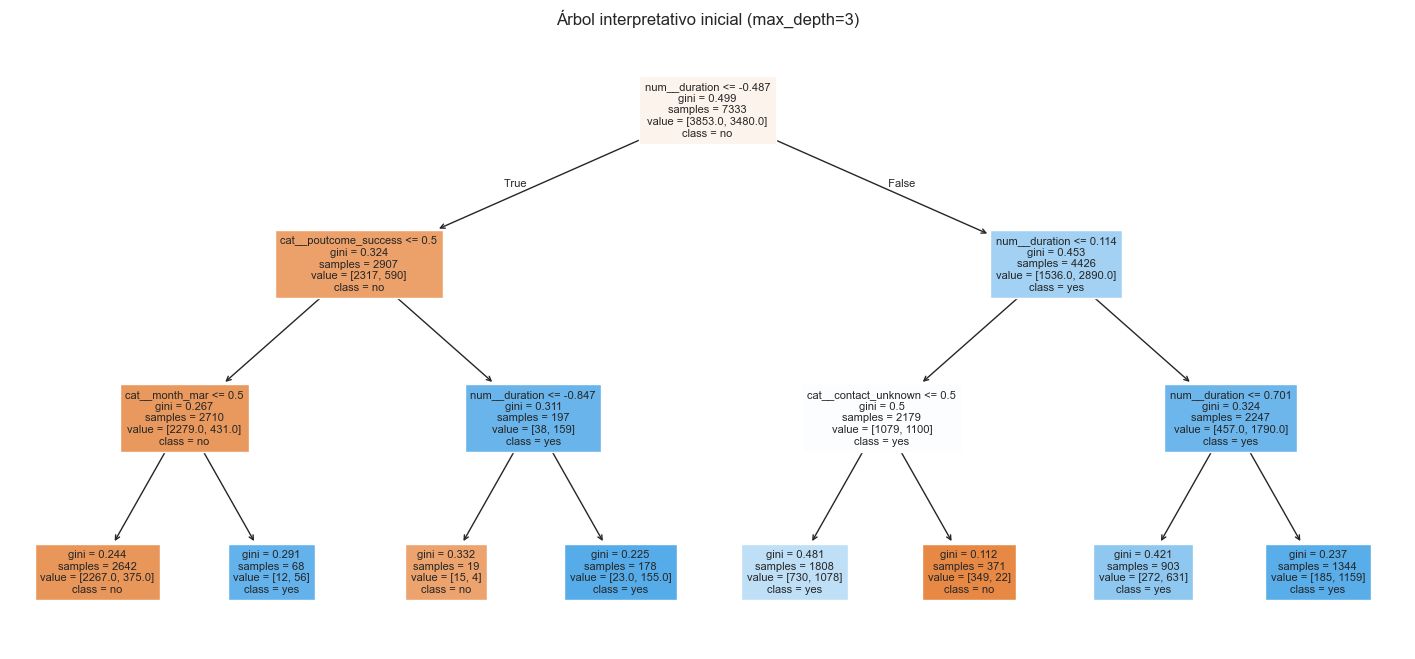

In [4]:
rows = []
rows.append(evaluate_default('Dummy (most_frequent)', DummyClassifier(strategy='most_frequent', random_state=SEED)))

for scaler in ['minmax', 'standard', 'robust']:
    rows.append(evaluate_default(f'KNN default ({scaler})', KNeighborsClassifier(), scaler_name=scaler))

best_scaler = max(rows[1:], key=lambda x: x['cv_f1_mean'])['model'].split('(')[-1].replace(')','')
rows.append(evaluate_default('Tree default', DecisionTreeClassifier(random_state=SEED), scaler_name='standard'))
rows.append(evaluate_default(f'KNN default ({best_scaler})', KNeighborsClassifier(), scaler_name=best_scaler))

results_defaults = pd.DataFrame(rows).sort_values('cv_f1_mean', ascending=False).reset_index(drop=True)
display(results_defaults)

interp_tree = build_pipeline(DecisionTreeClassifier(max_depth=3, random_state=SEED), scaler_name='standard')
interp_tree.fit(X_train, y_train)
tree_model = interp_tree.named_steps['model']
feature_names = interp_tree.named_steps['prep'].get_feature_names_out()

plt.figure(figsize=(18, 8))
plot_tree(tree_model, feature_names=feature_names, class_names=['no', 'yes'], filled=True, max_depth=3, fontsize=8)
plt.title('Árbol interpretativo inicial (max_depth=3)')
plt.show()

### Bloque 4 - Baseline de modelos

**Qué hace este bloque**
- Entrena y valida modelos base (Dummy, KNN con distintos escalados y Árbol).
- Muestra ranking inicial por F1 en validación cruzada.
- Dibuja un árbol interpretativo (`max_depth=3`).

**Reflexión**
- Este bloque fija una referencia mínima de rendimiento antes del ajuste fino.
- El árbol interpretativo ayuda a entender señales dominantes del problema, aunque no sea el mejor modelo final.

In [5]:
from sklearn.model_selection import GridSearchCV

# --- 1. HPO Árbol de Decisión ---
tree_pipe = build_pipeline(DecisionTreeClassifier(random_state=SEED), scaler_name='standard')
# Probamos profundidades del 1 al 20
tree_param_grid = {'model__max_depth': range(1, 21)}

print("Iniciando HPO para Árbol de Decisión...")
start_time = time.perf_counter()
tree_grid = GridSearchCV(
    tree_pipe, 
    tree_param_grid, 
    cv=inner_cv, 
    scoring=MAIN_METRIC, 
    n_jobs=-1, 
    return_train_score=True
)
tree_grid.fit(X_train, y_train)
tree_hpo_time = time.perf_counter() - start_time

print(f"Mejor max_depth: {tree_grid.best_params_['model__max_depth']}")
print(f"Mejor F1-Score (Validación): {tree_grid.best_score_:.4f}")
print(f"Tiempo de HPO: {tree_hpo_time:.2f} segundos\\n")


# --- 2. HPO KNN ---
knn_pipe = build_pipeline(KNeighborsClassifier(), scaler_name='standard')
# Probamos valores impares de vecinos del 1 al 40
knn_param_grid = {'model__n_neighbors': range(1, 41, 2)} 

print("Iniciando HPO para KNN...")
start_time = time.perf_counter()
knn_grid = GridSearchCV(
    knn_pipe, 
    knn_param_grid, 
    cv=inner_cv, 
    scoring=MAIN_METRIC, 
    n_jobs=-1, 
    return_train_score=True
)
knn_grid.fit(X_train, y_train)
knn_hpo_time = time.perf_counter() - start_time

print(f"Mejor n_neighbors: {knn_grid.best_params_['model__n_neighbors']}")
print(f"Mejor F1-Score (Validación): {knn_grid.best_score_:.4f}")
print(f"Tiempo de HPO: {knn_hpo_time:.2f} segundos")


Iniciando HPO para Árbol de Decisión...
Mejor max_depth: 9
Mejor F1-Score (Validación): 0.8171
Tiempo de HPO: 2.04 segundos\n
Iniciando HPO para KNN...
Mejor n_neighbors: 11
Mejor F1-Score (Validación): 0.7835
Tiempo de HPO: 5.87 segundos


### Bloque 5 - Ajuste de hiperparámetros (HPO)

**Qué hace este bloque**
- Ejecuta `GridSearchCV` para Árbol (profundidad) y KNN (número de vecinos).
- Reporta mejores hiperparámetros, F1 de validación y tiempo de búsqueda.

**Reflexión**
- El HPO suele mejorar la robustez frente al baseline y justifica mejor la elección del modelo.
- Además del score, mirar el tiempo de búsqueda aporta criterio práctico de coste computacional.

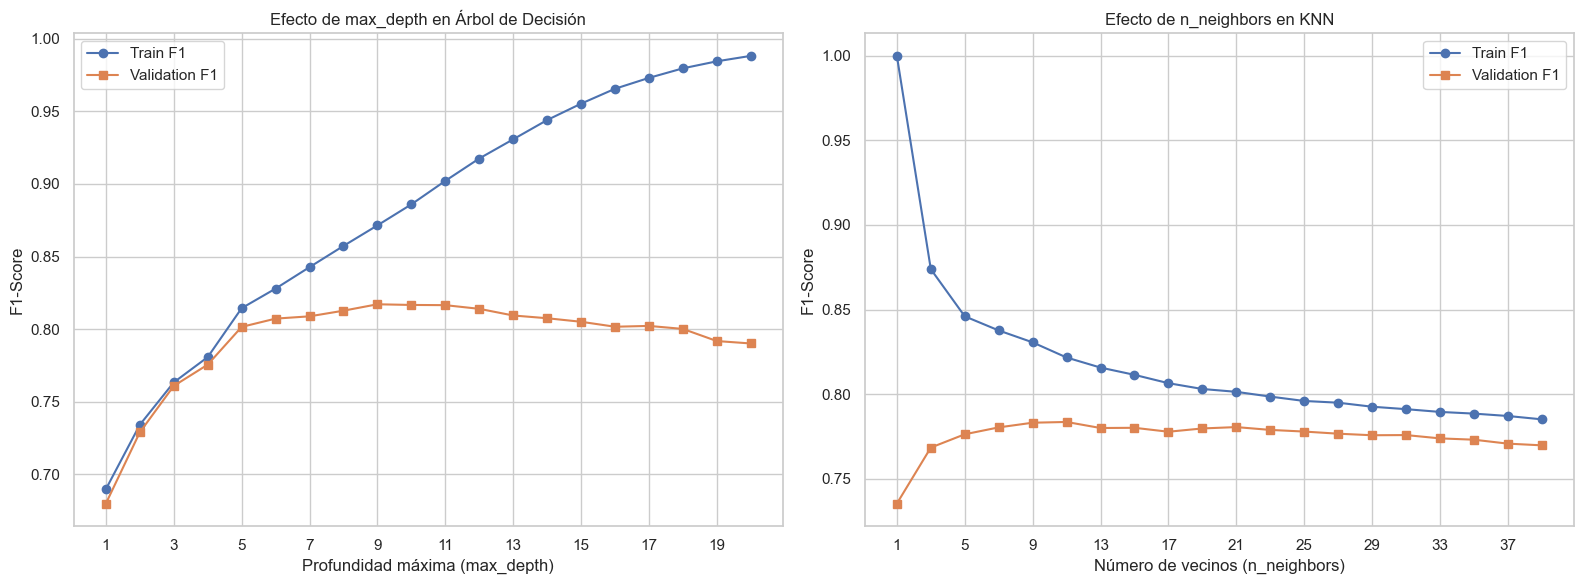

In [6]:
# --- 3. Gráficas del efecto de los hiperparámetros ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica Árbol de Decisión
tree_results = pd.DataFrame(tree_grid.cv_results_)
axes[0].plot(tree_results['param_model__max_depth'], tree_results['mean_train_score'], label='Train F1', marker='o')
axes[0].plot(tree_results['param_model__max_depth'], tree_results['mean_test_score'], label='Validation F1', marker='s')
axes[0].set_title('Efecto de max_depth en Árbol de Decisión')
axes[0].set_xlabel('Profundidad máxima (max_depth)')
axes[0].set_ylabel('F1-Score')
axes[0].set_xticks(range(1, 21, 2))
axes[0].legend()

# Gráfica KNN
knn_results = pd.DataFrame(knn_grid.cv_results_)
axes[1].plot(knn_results['param_model__n_neighbors'], knn_results['mean_train_score'], label='Train F1', marker='o')
axes[1].plot(knn_results['param_model__n_neighbors'], knn_results['mean_test_score'], label='Validation F1', marker='s')
axes[1].set_title('Efecto de n_neighbors en KNN')
axes[1].set_xlabel('Número de vecinos (n_neighbors)')
axes[1].set_ylabel('F1-Score')
axes[1].set_xticks(range(1, 41, 4))
axes[1].legend()

plt.tight_layout()
plt.show()

### Bloque 6 - Análisis visual del HPO

**Qué hace este bloque**
- Visualiza la evolución de F1 de entrenamiento y validación al variar `max_depth` y `n_neighbors`.

**Reflexión**
- Las curvas permiten detectar sobreajuste (train muy alto, validation estancada o a la baja).
- Esto ayuda a justificar por qué ciertos hiperparámetros generalizan mejor que otros.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import joblib

extra_rows = []
extra_rows.append({
    'model': 'Tree tuned (GridSearch)',
    'cv_f1_mean': float(tree_grid.best_score_),
    'time_seconds': float(tree_hpo_time),
})
extra_rows.append({
    'model': 'KNN tuned (GridSearch)',
    'cv_f1_mean': float(knn_grid.best_score_),
    'time_seconds': float(knn_hpo_time),
})

extra_rows.append(evaluate_default(
    'LogisticRegression default',
    LogisticRegression(max_iter=2000, random_state=SEED),
    scaler_name='standard'
))
extra_rows.append(evaluate_default(
    'SVM linear default',
    SVC(kernel='linear', random_state=SEED),
    scaler_name='standard'
))
extra_rows.append(evaluate_default(
    'SVM rbf default',
    SVC(kernel='rbf', random_state=SEED),
    scaler_name='standard'
))

results_extra = pd.DataFrame(extra_rows).sort_values('cv_f1_mean', ascending=False).reset_index(drop=True)
display(results_extra)

all_results = pd.concat([results_defaults, results_extra], ignore_index=True)
all_results = all_results.sort_values('cv_f1_mean', ascending=False).reset_index(drop=True)
print('Ranking global por F1 de validación:')
display(all_results)

,model,cv_f1_mean,time_seconds
0,SVM rbf default,0.848220,2.857006
1,SVM linear default,0.819452,2.965886
2,Tree tuned (GridSearch),0.817074,2.041745
3,LogisticRegression default,0.814743,0.192745
4,KNN tuned (GridSearch),0.783511,5.868390


Ranking global por F1 de validación:


,model,cv_f1_mean,time_seconds
0,SVM rbf default,0.848220,2.857006
1,SVM linear default,0.819452,2.965886
2,Tree tuned (GridSearch),0.817074,2.041745
3,LogisticRegression default,0.814743,0.192745
4,Tree default,0.786112,0.182302
5,KNN tuned (GridSearch),0.783511,5.868390
6,KNN default (standard),0.776231,3.029100
7,KNN default (standard),0.776231,0.182723
8,KNN default (robust),0.752552,2.772813
9,KNN default (minmax),0.693135,2.767610


Top 5 variables con más impacto:


,Variable,Coeficiente,Importancia_Absoluta
23,cat__marital_None,3.206562,3.206562
44,cat__month_mar,2.053329,2.053329
3,num__duration,1.865881,1.865881
51,cat__poutcome_success,1.561851,1.561851
41,cat__month_jan,-1.271088,1.271088


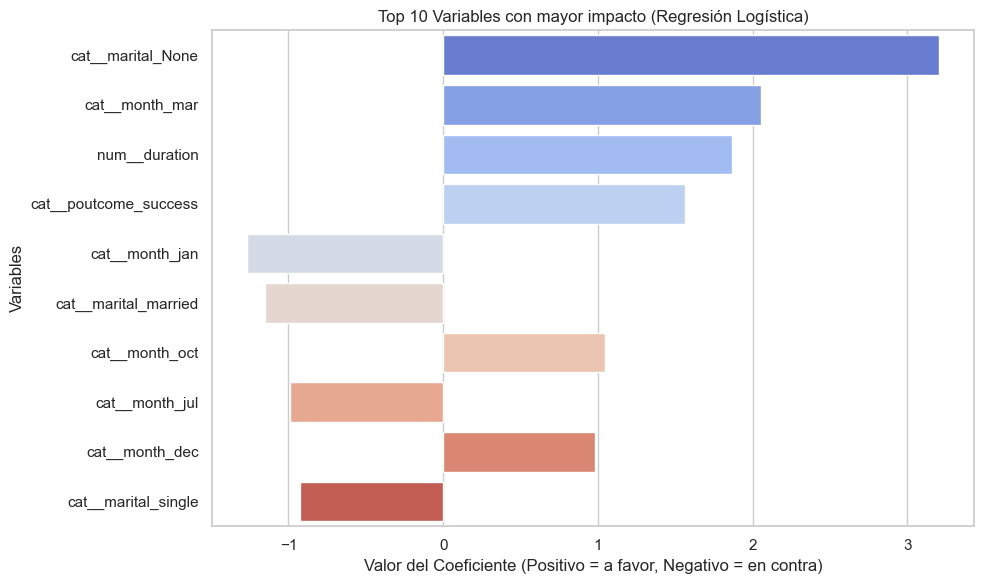

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# --- AÑADIDO: Entrenamos el modelo rápidamente por si no estaba en memoria ---
log_pipe = build_pipeline(LogisticRegression(random_state=SEED, max_iter=1000), scaler_name='standard')
log_pipe.fit(X_train, y_train)
# -----------------------------------------------------------------------------

# 1. Extraemos el modelo final y los nombres de las variables del pipeline
modelo_lineal = log_pipe.named_steps['model']
nombres_variables = log_pipe.named_steps['prep'].get_feature_names_out()

# 2. Extraemos los coeficientes y su valor absoluto
coeficientes = modelo_lineal.coef_[0]
importancia_df = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': np.abs(coeficientes)
}).sort_values(by='Importancia_Absoluta', ascending=False)

print("Top 5 variables con más impacto:")
display(importancia_df.head(5))

# 3. Dibujamos el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importancia_df.head(10), 
    x='Coeficiente', 
    y='Variable', 
    hue='Variable',
    palette='coolwarm',
    legend=False
)
plt.title('Top 10 Variables con mayor impacto (Regresión Logística)')
plt.xlabel('Valor del Coeficiente (Positivo = a favor, Negativo = en contra)')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

**Conclusión sobre la importancia de las variables (Modelo Lineal):**
Analizando los coeficientes extraídos de la Regresión Logística, podemos interpretar qué características influyen más en la predicción. Las variables con coeficientes positivos altos aumentan significativamente la probabilidad de que el cliente contrate el depósito. Por el contrario, las variables con coeficientes negativos fuertes empujan la predicción hacia el "no".

### Bloque 7 - Comparativa ampliada de modelos

**Qué hace este bloque**
- Integra al ranking los modelos ajustados y modelos adicionales (LogReg y SVM).
- Consolida un ranking global por F1 de validación.

**Reflexión**
- Este paso evita elegir modelo por intuición y centraliza la decisión en métricas comparables.
- Un ranking global facilita defender técnicamente la selección final.

Mejor candidato según validación: SVM rbf default
F1 en test: 0.8572

Reporte de clasificación en test:
              precision    recall  f1-score   support

          no       0.89      0.84      0.86      1927
         yes       0.83      0.88      0.86      1740

    accuracy                           0.86      3667
   macro avg       0.86      0.86      0.86      3667
weighted avg       0.86      0.86      0.86      3667



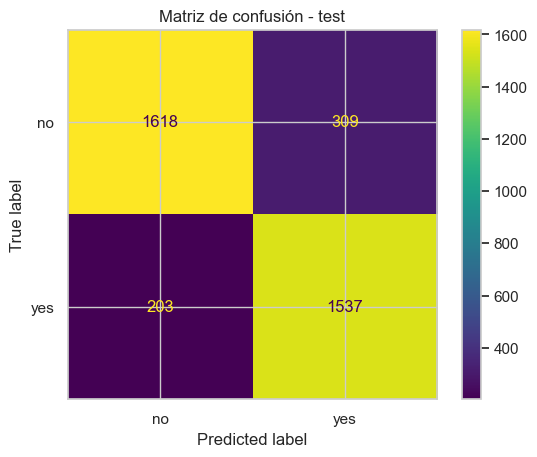

In [8]:
best_name = all_results.iloc[0]['model']
print(f'Mejor candidato según validación: {best_name}')

if best_name == 'Tree tuned (GridSearch)':
    final_model = tree_grid.best_estimator_
elif best_name == 'KNN tuned (GridSearch)':
    final_model = knn_grid.best_estimator_
elif best_name == 'LogisticRegression default':
    final_model = build_pipeline(
        LogisticRegression(max_iter=2000, random_state=SEED),
        scaler_name='standard'
    )
elif best_name == 'SVM linear default':
    final_model = build_pipeline(
        SVC(kernel='linear', random_state=SEED),
        scaler_name='standard'
    )
else:
    final_model = build_pipeline(
        SVC(kernel='rbf', random_state=SEED),
        scaler_name='standard'
    )

final_model.fit(X_train, y_train)
y_pred_test = final_model.predict(X_test)

test_f1 = f1_score(y_test, y_pred_test, pos_label='yes')
print(f'F1 en test: {test_f1:.4f}')
print('\nReporte de clasificación en test:')
print(classification_report(y_test, y_pred_test))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.title('Matriz de confusión - test')
plt.show()

## Tarea de elección abierta: Modelo Ensamblado (Random Forest)
Para cumplir con la tarea de elección abierta, hemos decidido implementar un **Random Forest Classifier**. Los ensamblados basados en árboles suelen ofrecer un rendimiento superior a los árboles individuales al reducir el sobreajuste (overfitting) promediando múltiples predicciones.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Construimos el pipeline para el Random Forest
rf_pipe = build_pipeline(RandomForestClassifier(random_state=SEED), scaler_name='standard')

print("Entrenando Random Forest (Tarea Abierta)...")
start_time = time.perf_counter()

# Evaluamos con validación cruzada (igual que hicisteis con los otros modelos)
rf_scores = cross_val_score(rf_pipe, X_train, y_train, cv=inner_cv, scoring=MAIN_METRIC, n_jobs=-1)

rf_time = time.perf_counter() - start_time

print(f"F1-Score Medio (Validación): {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
print(f"Tiempo de entrenamiento: {rf_time:.2f} segundos")

Entrenando Random Forest (Tarea Abierta)...
F1-Score Medio (Validación): 0.8526 (+/- 0.0049)
Tiempo de entrenamiento: 0.77 segundos


### Bloque 8 - Selección final y evaluación en test

**Qué hace este bloque**
- Selecciona automáticamente el mejor candidato según validación.
- Entrena el modelo final y evalúa sobre `test` con F1, classification report y matriz de confusión.

**Reflexión**
- Evaluar en test es clave para estimar rendimiento fuera de validación interna.
- La matriz de confusión permite entender dónde falla el modelo y si el error es aceptable para el caso de uso.

In [ ]:
joblib.dump(final_model, 'modelo_final.joblib')

pred_comp = final_model.predict(df_comp)
pred_df = pd.DataFrame({'deposit': pred_comp})
pred_df.to_csv('predicciones.csv', index=False)

print('Modelo guardado en modelo_final.joblib')
print('Predicciones guardadas en predicciones.csv')
print(pred_df['deposit'].value_counts())
pred_df.head()

### Bloque 9 - Exportación de artefactos finales

**Qué hace este bloque**
- Guarda el pipeline entrenado en `modelo_final.joblib`.
- Genera y exporta `predicciones.csv` para el conjunto de competición.

**Reflexión**
- Esta salida conecta directamente con la entrega y con el despliegue en Streamlit.
- Es importante mantener consistencia entre modelo exportado y CSV generado en la misma ejecución.

## Comentario de resultados

- El mejor candidato por validación cruzada fue **SVM con kernel RBF**.
- En test se obtuvo un **F1 = 0.8572** para la clase positiva (`yes`), con rendimiento equilibrado entre precisión y recall.
- La matriz de confusión muestra buen balance general, aunque siguen existiendo falsos positivos y falsos negativos esperables en un problema real.
- Se exportaron correctamente los dos artefactos finales de entrega: `modelo_final.joblib` y `predicciones.csv`.

Conclusión: el pipeline final queda listo para inferencia en notebook y para despliegue en la app de Streamlit.